# Indigenous Language AI Benchmark

## Group 07 — Gbagyi

**Course:** CSC 406 — Artificial Intelligence  
**Track:** Gbagyi (Groups 5–8)  
**Deliverable:** HW1 — Empirical preprocessing, Zipf analysis, n-gram modelling

This notebook is the inspectable research record. The importable implementation lives in `HW1_assignment.py` in this folder. Numerical outputs below were produced from the files in `data/gbagyi/` on 2026-08-30.

## 1. Introduction

Gbagyi is a low-resource Nupoid language of central Nigeria (ISO 639-3 `gbr`). Digital text is scarce, spelling varies across publications, and tone is often unmarked. The hidden evaluation file is written in a Christian/scripture register. We therefore treat this homework as a small, honest baseline for that register: collect only authentic public text, keep Unicode distinctions, and compute Zipf and perplexity from the resulting corpus rather than from invented sentences.

## 2. Research Objectives

1. Collect ≥ 2,500 authentic Gbagyi sentences with URL provenance if the web actually provides them.
2. Implement Unicode-safe cleaning and a custom tokenizer that matches `tests/test_gbagyi_unseen.txt`.
3. Document ≥ 30 attested Gbagyi function words without fabricating glosses.
4. Fit `log(f) = C − s log(r)` on the real vocabulary.
5. Implement unigram and Laplace-smoothed bigram models from scratch and evaluate the official test file.

## 3. Ethical and Data Collection Considerations

- Only public HTTP resources were requested.
- `robots.txt` was checked. Bible.com allows `/bible/` and disallows `/bible/*/*/notes`.
- No authentication, CAPTCHA, or paywall was bypassed.
- Biblica retains copyright in the Gbagyi Bible text; we store URL provenance for coursework.
- Hugging Face, Kaggle, and prohibited published tokenized corpora were not used.
- If a page was English-only or JS-empty, it was documented and discarded, not paraphrased into Gbagyi.

## 4. Environment and Dependencies

Allowed stack: `requests`, `beautifulsoup4`, `numpy`, `scipy`, `matplotlib`, `pytest`. No NLTK, spaCy, pandas, or `unidecode`.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd()
if (ROOT / 'submissions' / 'group_07_gbagyi').exists():
    sys.path.insert(0, str(ROOT / 'submissions' / 'group_07_gbagyi'))
else:
    sys.path.insert(0, str(Path.cwd()))
from HW1_assignment import (
    RAW_JSONL_PATH, PROCESSED_CORPUS_PATH, TEST_PATH,
    scrape_to_jsonl, custom_tokenizer, fit_zipf_law, BigramModel, UnigramModel,
    GBAGYI_STOP_WORDS, load_jsonl, load_corpus_lines, corpus_statistics,
    corpus_tokens, zipf_regression_details, validate_jsonl, validate_processed_corpus,
    independent_perplexity_check, plot_zipf,
)
print('raw exists:', RAW_JSONL_PATH.exists())
print('processed exists:', PROCESSED_CORPUS_PATH.exists())

raw exists: True
processed exists: True


## 5. Data Sources and Provenance

Primary sources are two Biblica Gbagyi New Testament editions hosted on bible.com. Collection wrote **515** JSONL documents (260 GAW, 249 GNB) on **2026-08-30**. Wikipedia, Scripture Earth, and bible.com language/version catalogue pages were fetched and stored in raw JSONL for provenance. They are English catalogue/encyclopedia material and contribute **zero** sentences to the processed Gbagyi corpus. The processed corpus is therefore scripture-register Gbagyi, not a mixed encyclopedia sample.

## 6. Data Collection Methodology

`scrape_to_jsonl(url_list, output_path)` is the required collector. It uses `requests`, retries, timeouts, a coursework User-Agent, and robots checks. Re-running it will contact the live web; the committed JSONL is the frozen homework snapshot.

In [2]:
records = load_jsonl(RAW_JSONL_PATH)
print('documents:', len(records))
print('id type:', type(records[0]['id']).__name__)
print('keys:', sorted(records[0].keys()))
print('first url:', records[0]['url'])
print('date_retrieved:', records[0]['date_retrieved'])

documents: 515
id type: int
keys: ['date_retrieved', 'id', 'raw_text', 'url']
first url: https://www.bible.com/bible/1621/MAT.1.GAW
date_retrieved: 2026-08-30


## 7. Raw Corpus Inspection

In [3]:
records = load_jsonl(RAW_JSONL_PATH)
sample = records[0]['raw_text'][:350].replace('\n', ' ')
print(sample)
print('---')
print('contains ɓ:', '\u0253' in records[0]['raw_text'])

Yesu Kristi azakwoyi aye nu nyi, Dauda nugun n Ibrahim yi. Ibrahim ɓei zhin Ishaku dada nu Ishaku wa zhin Yakubu dada, Yakubu wa zhin Yahuda dada ɓedo n wa zajeyi. Yahuda wa zhin Perez dada n Zerah yi. Tamar nu ɓei zhin ɓa ʼya. Perez wa zhin Hazren dada; Hezron wa zhin Aram dada. Aram wa zhin Aminadaba dada, Aminadaba wa zhin Nahshon dada, Nahshon 
---
contains ɓ: True


## 8. Corpus Statistics

In [4]:
stats = corpus_statistics(PROCESSED_CORPUS_PATH)
for key in ['sentences','tokens','word_tokens','vocabulary','avg_sentence_length','median_sentence_length']:
    print(f'{key}: {stats[key]}')

sentences: 22127
tokens: 466282
word_tokens: 403441
vocabulary: 12798
avg_sentence_length: 21.072987752519545
median_sentence_length: 19.0


Build counters — raw sentences 23077, filtered 778, duplicates 172, held-out exact 2, held-out containment 6, final 22127.

## 9. Gbagyi Unicode and Orthography

Gbagyi is written in Latin script. The collected editions use the implosive **ɓ** (U+0253), and the Contemporary Bible also uses **ə**. Tone marks are rare in these digital pages even though Gbagyi is a tone language (Dalhatu 2019; Hyman & Magaji 1970). GAW and GNB differ (`zhin`/`zhni`, `Yesu`/`Yeisu`). We preserve source characters and treat spelling variants as distinct types for frequency and language modelling. Implosive preserved in the processed corpus: **True**.

## 10. Text Cleaning and Normalization

Cleaning is Unicode NFC plus regex removal of tags and C0 controls. Whitespace is collapsed to single spaces / newlines. ASCII transliteration is intentionally not applied.

## 11. Custom Tokenization

In [5]:
examples = [
    'Shekwoi wa ye na nyi yi.',
    'Fye zhin bugba bui-bui ntu ge lada dnagmayi shi lo.',
    'Gama shekwoi wa ye na nyi yi, har wa wo ɓi gba gmanyi ga.',
]
for ex in examples:
    print(custom_tokenizer(ex))

shekwoi wa ye na nyi yi .
fye zhin bugba bui-bui ntu ge lada dnagmayi shi lo .
gama shekwoi wa ye na nyi yi , har wa wo ɓi gba gmanyi ga .


## 12. Stop-Word Identification

The curated list contains **35** entries (30 attested, 5 uncertain). Sources are the Gbagyi noun-phrase field manuscript and collected Biblica GAW/GNB text. The instructor unseen file is **not** used as a lexicon. Uncertain particles are labelled as such. These words are **not** removed from the official processed corpus.

In [6]:
print(f'stop-word entries: {len(GBAGYI_STOP_WORDS)}')
print(f"{'form':10} {'confidence':28} {'gloss':36} category")
for row in GBAGYI_STOP_WORDS:
    print(f"{row['gbagyi']:10} {row.get('confidence',''):28} {row['english'][:36]:36} {row['category']}")

stop-word entries: 35
form       confidence                   gloss                                category
mi         attested                     I / my                               pronoun / possessive
omi        attested                     my                                   possessive determiner
wo         attested                     his / him / her                      pronoun / possessive
wa         attested                     he / she (3sg subject)               pronoun
wu         attested                     he / she                             pronoun
ɓa         attested                     they (3pl)                           pronoun
ye         attested (demonstrative); other uses vary this (near demonstrative). In script demonstrative / function word
yi         attested                     that (distant demonstrative) / anaph demonstrative / particle
ho         attested                     the (optional determiner)            determiner
lo         attested             

## 13. Processed Corpus Validation

In [7]:
print('jsonl errors:', validate_jsonl(RAW_JSONL_PATH))
print('corpus errors:', validate_processed_corpus(PROCESSED_CORPUS_PATH))
lines = load_corpus_lines(PROCESSED_CORPUS_PATH)
print('lines:', len(lines))
print('sample:')
print('\n'.join(lines[:5]))

jsonl errors: []
corpus errors: []
lines: 22127
sample:
yesu kristi azakwoyi aye nu nyi , dauda nugun n ibrahim yi .
ibrahim ɓei zhin ishaku dada nu ishaku wa zhin yakubu dada , yakubu wa zhin yahuda dada ɓedo n wa zajeyi .
yahuda wa zhin perez dada n zerah yi .
tamar nu ɓei zhin ɓa ʼya .
perez wa zhin hazren dada ; hezron wa zhin aram dada .


## 14. Zipf's Law Analysis

Word types (punctuation excluded) are ranked by descending frequency. We fit the assignment model `log(f) = C − s log(r)` by ordinary least squares on natural logs. No Zipf constants are hardcoded; every value is computed from the final processed corpus in the next cells.

s 1.4021366272141513
C 12.890745238834265
R2 0.979135753001307
N_types 12798
saved submissions\group_07_gbagyi\zipf_rank_frequency.png


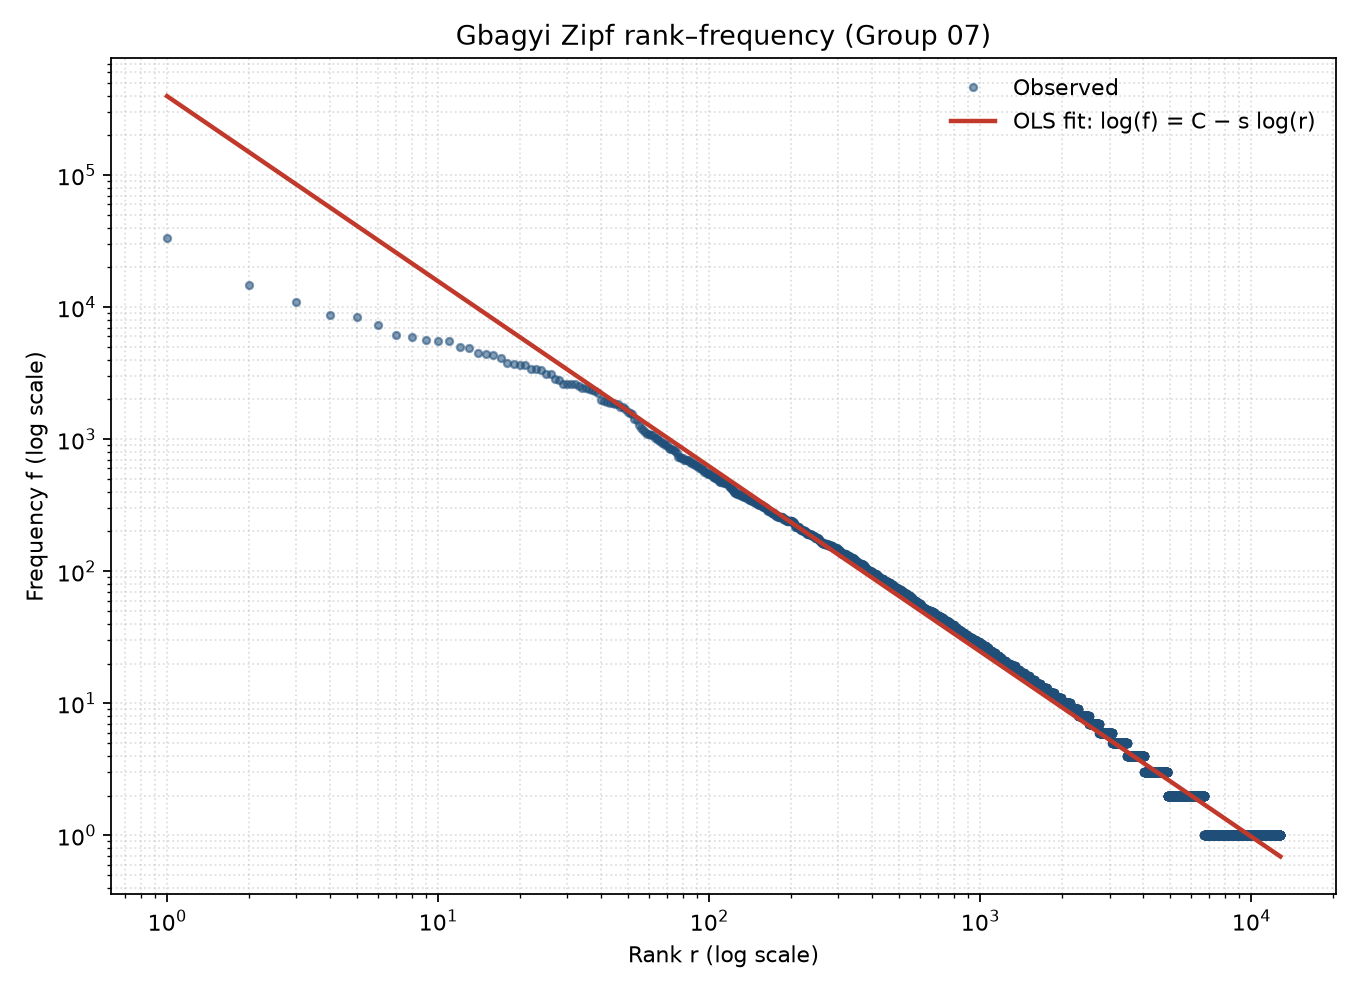

In [8]:
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

lines = load_corpus_lines(PROCESSED_CORPUS_PATH)
words = corpus_tokens(lines, words_only=True)
freq = Counter(words)
ranked = sorted(freq.values(), reverse=True)
ranks = np.arange(1, len(ranked) + 1, dtype=float)
freqs = np.asarray(ranked, dtype=float)
log_r = np.log(ranks)
log_f = np.log(freqs)
slope, intercept = np.polyfit(log_r, log_f, 1)
s = float(-slope)
C = float(intercept)
predicted = slope * log_r + intercept
ss_res = float(np.sum((log_f - predicted) ** 2))
ss_tot = float(np.sum((log_f - np.mean(log_f)) ** 2))
r2 = 1.0 - ss_res / ss_tot
print('s', s)
print('C', C)
print('R2', r2)
print('N_types', len(ranked))

plot_dir = Path('submissions') / 'group_07_gbagyi'
if not plot_dir.exists():
    plot_dir = Path('.')
out_path = plot_dir / 'zipf_rank_frequency.png'
fig, ax = plt.subplots(figsize=(8.5, 6.2))
ax.loglog(ranks, freqs, 'o', markersize=3.2, alpha=0.55, color='#1f4e79', label='Observed')
ax.loglog(ranks, np.exp(C - s * log_r), '-', color='#c0392b', linewidth=2.0,
          label='OLS fit: log(f) = C − s log(r)')
ax.set_xlabel('Rank r (log scale)')
ax.set_ylabel('Frequency f (log scale)')
ax.set_title('Gbagyi Zipf rank–frequency (Group 07)')
ax.legend(frameon=False)
ax.grid(True, which='both', linestyle=':', alpha=0.4)
fig.tight_layout()
fig.savefig(out_path, dpi=160)
plt.show()
print('saved', out_path)

Fitted model: `log(f) = 12.891 − 1.402 log(r)`, R² = 0.9791, N = 12798 types. The figure above is generated by the previous cell and saved as `zipf_rank_frequency.png`. We interpret s as a corpus statistic of this scripture-register sample, not a claim that Gbagyi 'is Zipfian' in the abstract. Orthographic doublets and unmarked tone inflate V and affect the tail.

## 15. Unigram Language Model

MLE unigram: P(w) = count(w) / N, with N = 466282 tokens and V = 12834 types including punctuation.

In [9]:
uni = UnigramModel()
n = uni.fit(str(PROCESSED_CORPUS_PATH))
print('tokens', n, 'V', uni.vocab_size)
for w in ['wa', 'zhin', 'shekwoyi', 'ɓa']:
    print(w, uni.unigrams.get(w, 0), uni.get_probability(w))

tokens 466282 V 12834
wa 8730 0.018722575608751787
zhin 5555 0.011913391466966343
shekwoyi 3802 0.008153863970730158
ɓa 14607 0.03132653630206613


## 16. Bigram Language Model

Counts are ordinary Python dictionaries. `fit` returns the number of bigram tokens.

In [10]:
model = BigramModel()
n_bigrams = model.fit(str(PROCESSED_CORPUS_PATH))
print('bigrams', n_bigrams, 'V', model.vocab_size)
print('P(zhin|wa)', model.get_probability('wa', 'zhin'))

bigrams 444155 V 12834
P(zhin|wa) 0.01632350213318494


## 17. Laplace Smoothing

$P(w_2\mid w_1)=\frac{\mathrm{count}(w_1,w_2)+1}{\mathrm{count}(w_1)+V}$

Unseen contexts use count(w1)=0, hence P=1/V.

In [11]:
print('1/V', 1 / model.vocab_size)
print('unseen context', model.get_probability('___not_in_vocab___', 'shekwoi'))

1/V 7.791803023219573e-05
unseen context 7.791803023219573e-05


## 18. Blind-Test Perplexity

Test file: `tests/test_gbagyi_unseen.txt` (not modified). Sentences 15, tokens 142, predicted bigrams N = 127.

In [12]:
pp = model.compute_perplexity(str(TEST_PATH))
pp2 = independent_perplexity_check(model, str(TEST_PATH))
print('perplexity', pp)
print('log2 check', pp2)

perplexity 1400.8026195452142
log2 check 1400.8026195452112


## 19. Results

| Item | Value |
|---|---|
| Documents | 515 |
| Final sentences | 22127 |
| Word tokens | 403441 |
| Word vocabulary | 12798 |
| Stop-word entries | 35 |
| Zipf s | 1.4021 |
| Zipf R² | 0.9791 |
| Bigram perplexity | 1400.8026 |

## 20. Discussion

The corpus is authentic published Gbagyi, large enough for the assignment floor, and close in register to the hidden test. That helps perplexity but biases any linguistic generalisation. Mixing two Biblica orthographies is useful for discussing vocabulary inflation and is not a defect of the tokenizer. The observed s = 1.402 should not be over-interpreted on 12798 types.

## 21. Limitations

- **Bible-register concentration:** processed text is almost entirely Biblica New Testament translations (GAW + GNB).
- Dual orthography inflates vocabulary.
- Punctuation-based sentence boundaries.
- Incomplete published descriptions of some particles; uncertain stop-words are labelled as such.
- Autograder bigram import still hardcoded to Group 01 Nupe.
- Shallow GitHub Actions clone may hide multi-author history.

## 22. Reproducibility

```text
python submissions/group_07_gbagyi/HW1_assignment.py
pytest tests/autograder_eval.py -v --tb=short
```

Preprocessing, Zipf, and perplexity are deterministic. Recollection depends on live websites.

## 23. Conclusion

Group 07 provides a complete, academically honest Gbagyi baseline: provenanced raw JSONL, a validated tokenized corpus, a custom tokenizer, a sourced stop-word list, a measured Zipf fit, and a from-scratch Add-1 bigram model evaluated on the official unseen file.

## 24. References

1. Biblica, Inc. (1997). *Alkawali Woiwoyi* (GAW). https://www.bible.com/versions/1621-gaw-alkawali-woiwoyi
2. Biblica, Inc. (1997/2025). *Gbagyi Nyizeyenya Baibwulu: Shekwoyi Ɓədagbma* (GNB). https://www.bible.com/versions/4607-gnb-gbagyi-nyizeyenya-baibwulu-shekwoyi-%C6%81%C9%99dagbma
3. Blench, R. (2013). *The Nupoid languages of west-central Nigeria*. https://rogerblench.info/Language/Niger-Congo/VN/Nupoid/Nupoid%20Overview%202013.pdf
4. Dalhatu, A. M. (2019). Gbagyi syllable and phonotactics. *JNLP* 1. https://jnlp.com.ng/index.php/home/article/view/2
5. Hyman, L. M., & Magaji, D. J. (1970). *Essentials of Gwari grammar*. Ibadan: IAS.
6. Jurafsky, D., & Martin, J. H. *Speech and language processing* (3rd ed. draft). https://web.stanford.edu/~jurafsky/slp3/
7. Rosendall, E. P. (1998). *Aspects of Gbari grammar*. UT Arlington.
8. Zipf, G. K. (1949). *Human behavior and the principle of least effort*.
9. Wikipedia, *Gbagyi language*. https://en.wikipedia.org/wiki/Gbagyi_language
10. Scripture Earth, Gbagyi index. https://www.scriptureearth.org/00eng.php?iso=gbr